# Tree-based Models

In [150]:
%load_ext autoreload
%reload_ext autoreload
%autoreload 2

# system
import os
from pathlib import Path
import sys
sys.path.append(str(Path().resolve().parents[2]))  # workaround to resolve my helper module above

# dataframe
import polars as pl
import polars.selectors as cs

# modules
from modules.plotting import *
from modules.polars_helpers import *

# math
from scipy.stats import pearsonr
import numpy as np

# machine learning
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
# from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, KFold, cross_validate, cross_val_predict
from sklearn.metrics import precision_recall_curve, roc_curve, auc
from xgboost import XGBClassifier, XGBRFClassifier
from sklearn.svm import SVC
from skopt import BayesSearchCV
from skopt.space import Real, Integer
from sklearn.linear_model import LogisticRegression
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline

parent_dir = Path.cwd().parent

DATA_PATH = str(parent_dir / "data") + "/"
print(DATA_PATH)

RANDOM_SEED = 42

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
/Users/luiscruz/Desktop/kaggle_challenges/classification/facebook-recruiting-iv-human-or-bot/data/


In [122]:
train = pl.read_csv(DATA_PATH + "train.csv")
test = pl.read_csv(DATA_PATH + "test.csv")

bids = pl.read_csv(DATA_PATH + "bids.csv")

The goal of this notebook is to model the data using tree based models such as Random Forests, XGBoost, perhaps Catboost too.

Considering all models here will be tree-based and use an sklearn-like API, we can define pipelines to label encode data. We can label encode data considering the magnitude or ordinal importance of categories is of very low value for the model, because it will just split on the numbers representing categories

In [3]:
def create_features(bidders_df: pl.DataFrame, bids: pl.DataFrame) -> pl.DataFrame:
    bids = bids.drop_nulls()

    # devices per bidder
    n_devices_per_bidder = bids.group_by("bidder_id").n_unique().select(["bidder_id", "device"])
    bidders_df = bidders_df.join(n_devices_per_bidder, on="bidder_id", how="left")

    # auction count per bidder
    auction_count_per_bidder = bids.group_by("bidder_id").n_unique().select(["bidder_id", "auction"])
    bidders_df = bidders_df.join(auction_count_per_bidder, on="bidder_id", how="left")

    # merchandise per bidder
    max_kind_of_merch_per_bidder = bids.group_by("bidder_id").max().select(["bidder_id", "merchandise"])
    bidders_df = bidders_df.join(max_kind_of_merch_per_bidder, on="bidder_id", how="left")

    # number of ips per bidder
    ip_count_per_bidder = bids.group_by("bidder_id").n_unique().select(["bidder_id", "ip"])
    bidders_df = bidders_df.join(ip_count_per_bidder, on="bidder_id", how="left")

    # different URLs per bidder
    url_count_per_bidder = bids.group_by("bidder_id").n_unique().select(["bidder_id", "url"])
    bidders_df = bidders_df.join(url_count_per_bidder, on="bidder_id", how="left")

    # most occurring country per bidder
    country_counts = (
        bids
        .group_by(["bidder_id", "country"])
        .agg(pl.count().alias("country_count"))
    )

    max_country_per_bidder = (
        country_counts
        .sort(["bidder_id", "country_count"], descending=[False, True])
        .group_by("bidder_id")
        .agg([
            pl.first("country").alias("most_frequent_country")
        ])
    )

    bidders_df = bidders_df.join(max_country_per_bidder, on="bidder_id", how="left")

    # time delta between bids
    bids = bids.sort(["bidder_id", "time"], descending=False).with_columns(
        pl.col("time").diff().over("bidder_id").fill_null(0).alias("diff_last_bid")
    )

    mean_time_diff_bids = bids.group_by("bidder_id").agg(
        pl.col("diff_last_bid").mean().alias("mean_diff_time_bids")
    )

    bidders_df = bidders_df.join(mean_time_diff_bids, on="bidder_id", how="left")

    # num of bids per bidder
    bid_counts = bids.group_by("bidder_id").agg(
        pl.n_unique("bid_id").alias("bid_count")
    )

    bidders_df = bidders_df.join(bid_counts, on="bidder_id", how="left")

    # handling missing values after feature creation
    numerical_cols = bidders_df.select(cs.by_dtype(pl.NUMERIC_DTYPES)).columns
    numerical_cols = filter(lambda x: x != "outcome", numerical_cols)

    bidders_df = bidders_df.with_columns([
        pl.col("most_frequent_country").fill_null("unknown"),
        pl.col("merchandise").fill_null("unknown"),
        pl.col("bidder_id").is_in(bids["bidder_id"]).alias("has_bids"),
    ]).with_columns(
        pl.col(num_col).fill_null(0) for num_col in numerical_cols
    )

    return bidders_df

In [123]:
train = create_features(train, bids)
test_processed = create_features(test, bids)

/var/folders/jq/tdq0h8rj1zdbxsbs18vhfp0h0000gp/T/ipykernel_51126/1719720841.py:28: DeprecationWarning: `pl.count()` is deprecated. Please use `pl.len()` instead.
  .agg(pl.count().alias("country_count"))
/var/folders/jq/tdq0h8rj1zdbxsbs18vhfp0h0000gp/T/ipykernel_51126/1719720841.py:61: DeprecationWarning: `NUMERIC_DTYPES` is deprecated. Define your own data type groups or use the `polars.selectors` module for selecting columns of a certain data type.
  numerical_cols = bidders_df.select(cs.by_dtype(pl.NUMERIC_DTYPES)).columns
/var/folders/jq/tdq0h8rj1zdbxsbs18vhfp0h0000gp/T/ipykernel_51126/1719720841.py:64: DeprecationWarning: `is_in` with a collection of the same datatype is ambiguous and deprecated.
Please use `implode` to return to previous behavior.

See https://github.com/pola-rs/polars/issues/22149 for more information.
  bidders_df = bidders_df.with_columns([


In [5]:
train.schema

Schema([('bidder_id', String),
        ('payment_account', String),
        ('address', String),
        ('outcome', Float64),
        ('device', UInt32),
        ('auction', UInt32),
        ('merchandise', String),
        ('ip', UInt32),
        ('url', UInt32),
        ('most_frequent_country', String),
        ('mean_diff_time_bids', Float64),
        ('bid_count', UInt32),
        ('has_bids', Boolean)])

In [6]:
train.head(3)

bidder_id,payment_account,address,outcome,device,auction,merchandise,ip,url,most_frequent_country,mean_diff_time_bids,bid_count,has_bids
str,str,str,f64,u32,u32,str,u32,u32,str,f64,u32,bool
"""91a3c57b13234af24875c56fb7e2b2…","""a3d2de7675556553a5f08e4c88d2c2…","""a3d2de7675556553a5f08e4c88d2c2…",0.0,14,18,"""home goods""",20,1,"""ke""",5.4732e11,24,true
"""624f258b49e77713fc34034560f93f…","""a3d2de7675556553a5f08e4c88d2c2…","""ae87054e5a97a8f840a3991d12611f…",0.0,2,1,"""office equipment""",3,2,"""id""",2.1557e12,3,true
"""1c5f4fc669099bfbfac515cd26997b…","""a3d2de7675556553a5f08e4c88d2c2…","""92520288b50f03907041887884ba49…",0.0,2,4,"""sporting goods""",4,2,"""id""",1.7842e12,4,true


In [7]:
numeric_features = ["mean_diff_time_bids", "bid_count", "auction", "device", "ip", "url"]
cat_features = [
    "has_bids",
    "merchandise",
    "most_frequent_country",
]

In [8]:
col_transformer = ColumnTransformer(
    transformers=[
        ("cat", LabelEncoder(), cat_features),
        ("num", StandardScaler(), numeric_features)
])

In [9]:
kfold = KFold(n_splits=5)

In [10]:
X = train.drop(["payment_account", "address", "bidder_id", "outcome"])
y = train["outcome"]

In [11]:
X_label_enc = X.with_columns(
    pl.lit(LabelEncoder().fit_transform(X["has_bids"])).alias("has_bids"),
    pl.lit(LabelEncoder().fit_transform(X["merchandise"])).alias("merchandise"),
    pl.lit(LabelEncoder().fit_transform(X["most_frequent_country"])).alias("most_frequent_country"),
)

X_label_enc

device,auction,merchandise,ip,url,most_frequent_country,mean_diff_time_bids,bid_count,has_bids
u32,u32,i64,u32,u32,i64,f64,u32,i64
14,18,5,20,1,35,5.4732e11,24,1
2,1,8,3,2,27,2.1557e12,3,1
2,4,9,4,2,27,1.7842e12,4,1
1,1,1,1,1,43,0.0,1,1
53,23,8,123,91,29,7.7277e10,155,1
…,…,…,…,…,…,…,…,…
4,25,7,5,2,68,2.0409e12,36,1
1,1,7,1,1,67,0.0,1,1
2,1,7,2,1,27,4.8992e12,2,1


## Random Forest Classifier

### Baseline

In [12]:
rf = RandomForestClassifier(random_state=RANDOM_SEED)

In [13]:
y_prob_rf = cross_val_predict(rf, X_label_enc, y, cv=kfold, n_jobs=-1, method="predict_proba")
y_scores = y_prob_rf[:, 1]

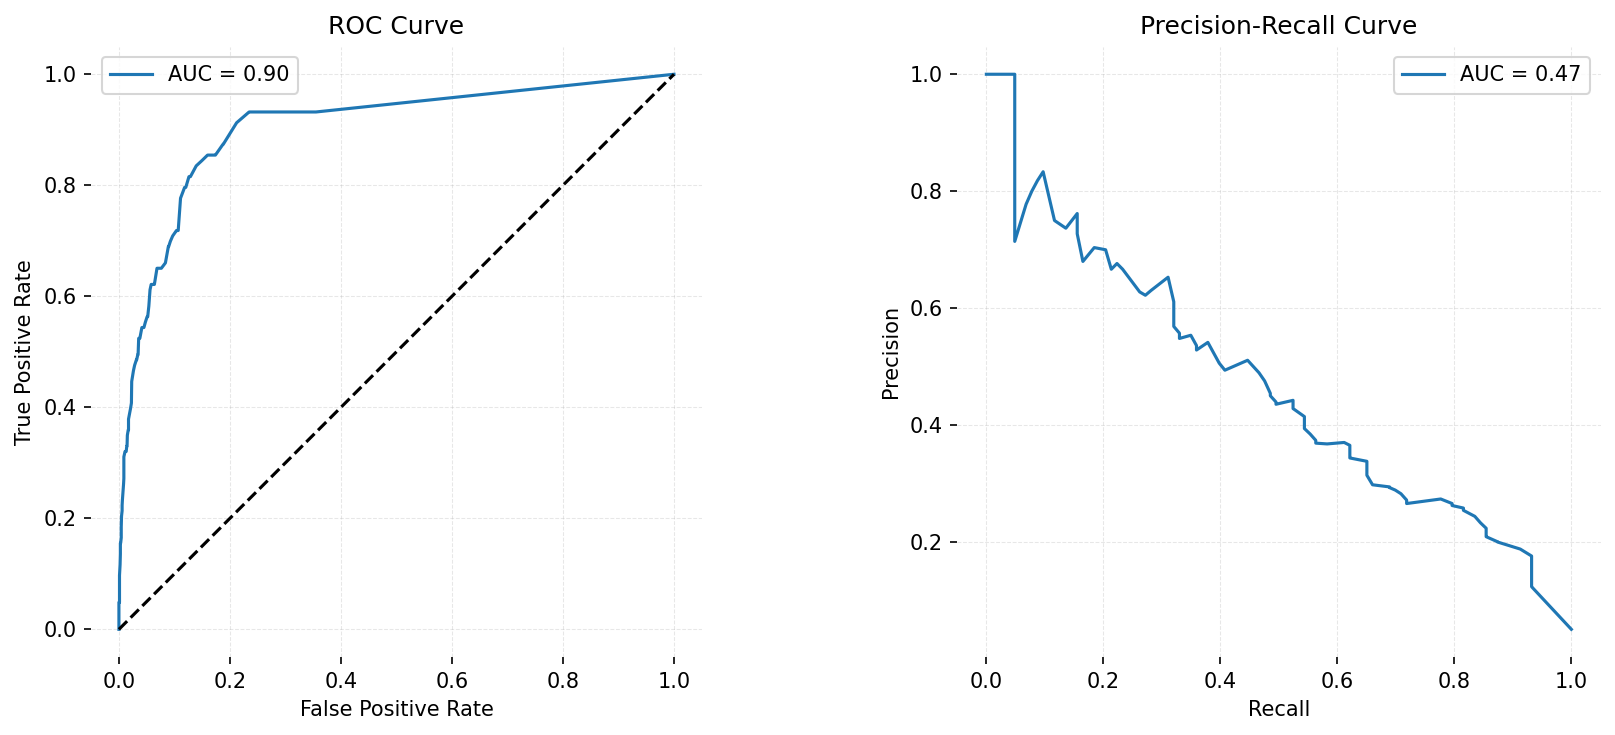

In [14]:
compute_and_plot_pr_roc_auc(y, y_scores)

## XGBoost Classifier

In [15]:
scale_pos_weight = np.sqrt((y == 0).sum() / (y == 1).sum())
scale_pos_weight

4.3062384188974425

### Baseline

In [16]:
xgb_clf = XGBClassifier(scale_pos_weight = scale_pos_weight, random_state=RANDOM_SEED)

In [17]:
y_prob_xgb = cross_val_predict(xgb_clf, X_label_enc, y, cv=kfold, n_jobs=-1, method="predict_proba")
y_scores_xgb = y_prob_xgb[:, 1]

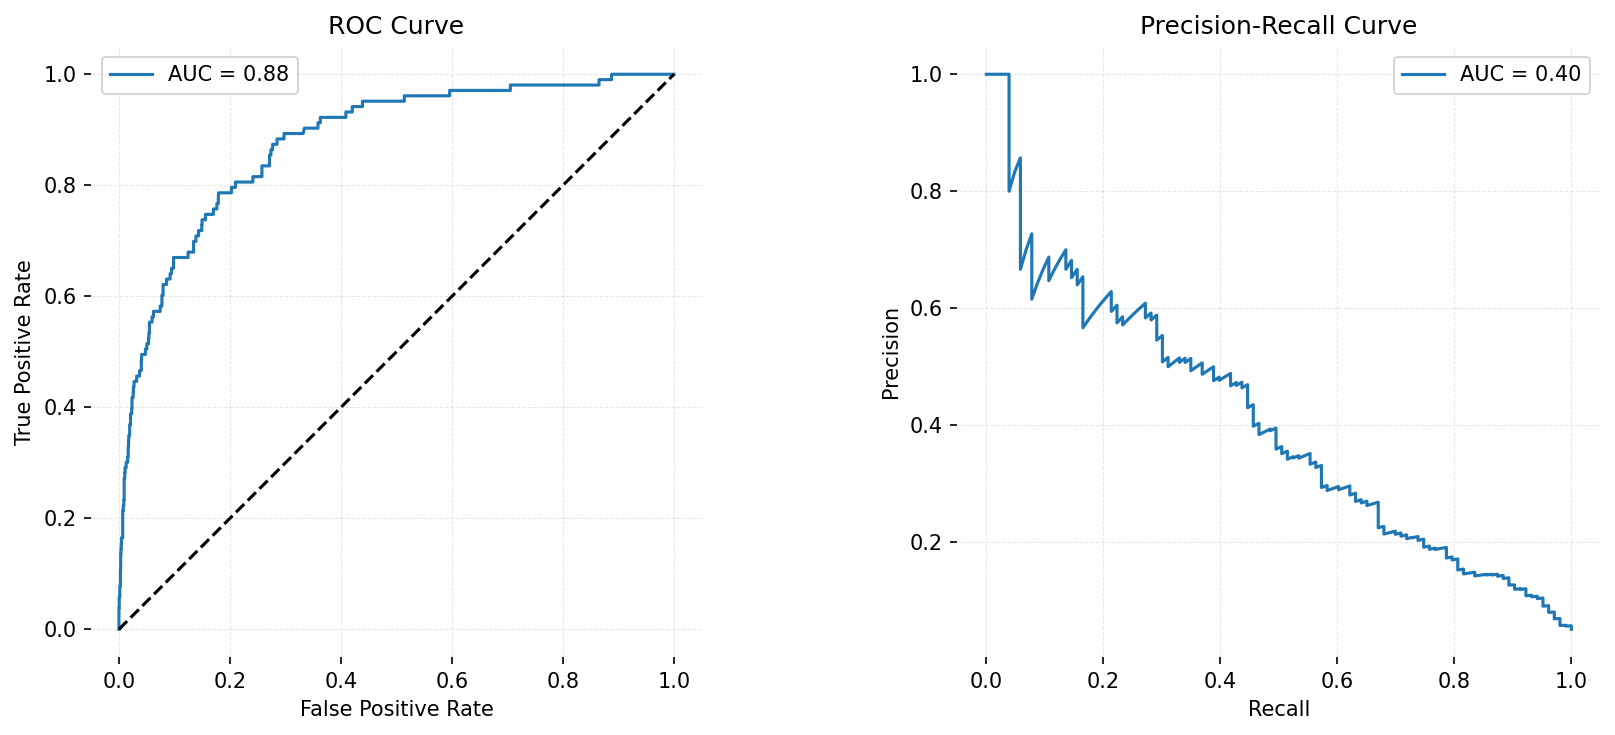

In [18]:
compute_and_plot_pr_roc_auc(y, y_scores_xgb)

## XGBoost Random Forest

### Baseline

In [115]:
xgbrf_clf = XGBRFClassifier(objective="binary:logistic", scale_pos_weight = scale_pos_weight, random_state=RANDOM_SEED)

In [116]:
y_prob_xgbrf = cross_val_predict(xgbrf_clf, X_label_enc, y, cv=kfold, n_jobs=-1, method="predict_proba")
y_scores_xgbrf = y_prob_xgbrf[:, 1]

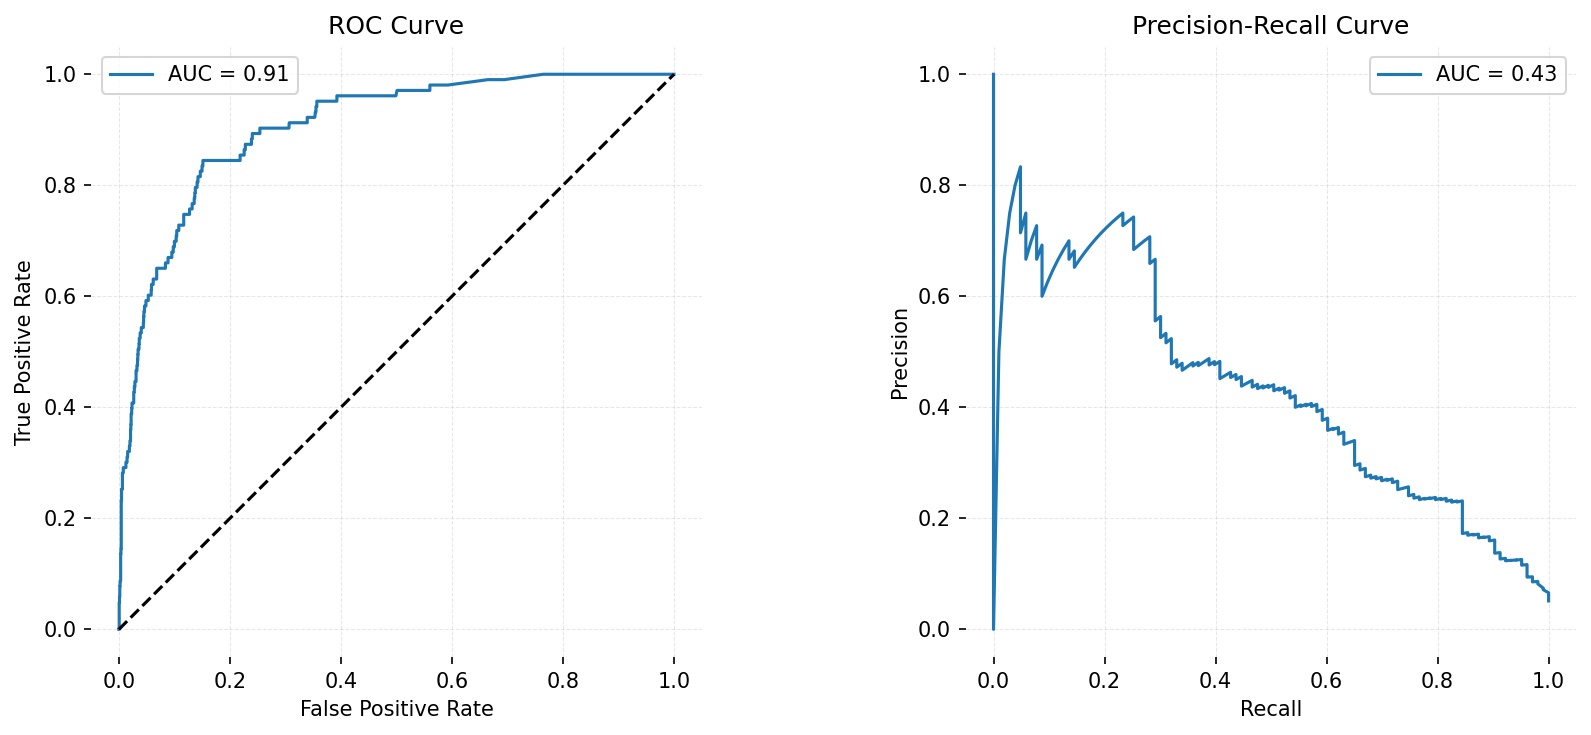

In [117]:
compute_and_plot_pr_roc_auc(y, y_scores_xgbrf)

XGBoost Random Forest improved slightly on sklearn's random forest, but the precision-recall curve is still very much unstable. That is most likely a dataset issue and not something the model can compensate for by itself

### Hyperparameter Search

In [118]:
search_space = {
    "n_estimators": Integer(5, 500),
    "max_depth": Integer(2, 20),
    "learning_rate": Real(0.0001, 0.2, prior="log-uniform"),
    "subsample": Real(0.5, 1.0),
    "colsample_bynode": Real(0.4, 1.0)
}

In [120]:
xgbrf = XGBRFClassifier(
    n_jobs=-1,
    random_state=RANDOM_SEED,
    scale_pos_weight=scale_pos_weight
)

search = BayesSearchCV(
    estimator=xgbrf,
    search_spaces=search_space,
    n_iter=100,
    scoring="roc_auc",
    cv=kfold,
    verbose=0,
    n_jobs=-1,
    random_state=RANDOM_SEED
)

search.fit(X_label_enc, y)

xgbrf_best = search.best_estimator_
print("Best parameters:", search.best_params_)

y_prob_xgbrf_bcv = cross_val_predict(
    xgbrf_best, X_label_enc, y, cv=kfold, n_jobs=-1, method="predict_proba"
)
y_scores_xgbrf_bcv = y_prob_xgbrf_bcv[:, 1]

Best parameters: OrderedDict([('colsample_bynode', 0.4), ('learning_rate', 0.0403941445367114), ('max_depth', 7), ('n_estimators', 432), ('subsample', 0.5)])


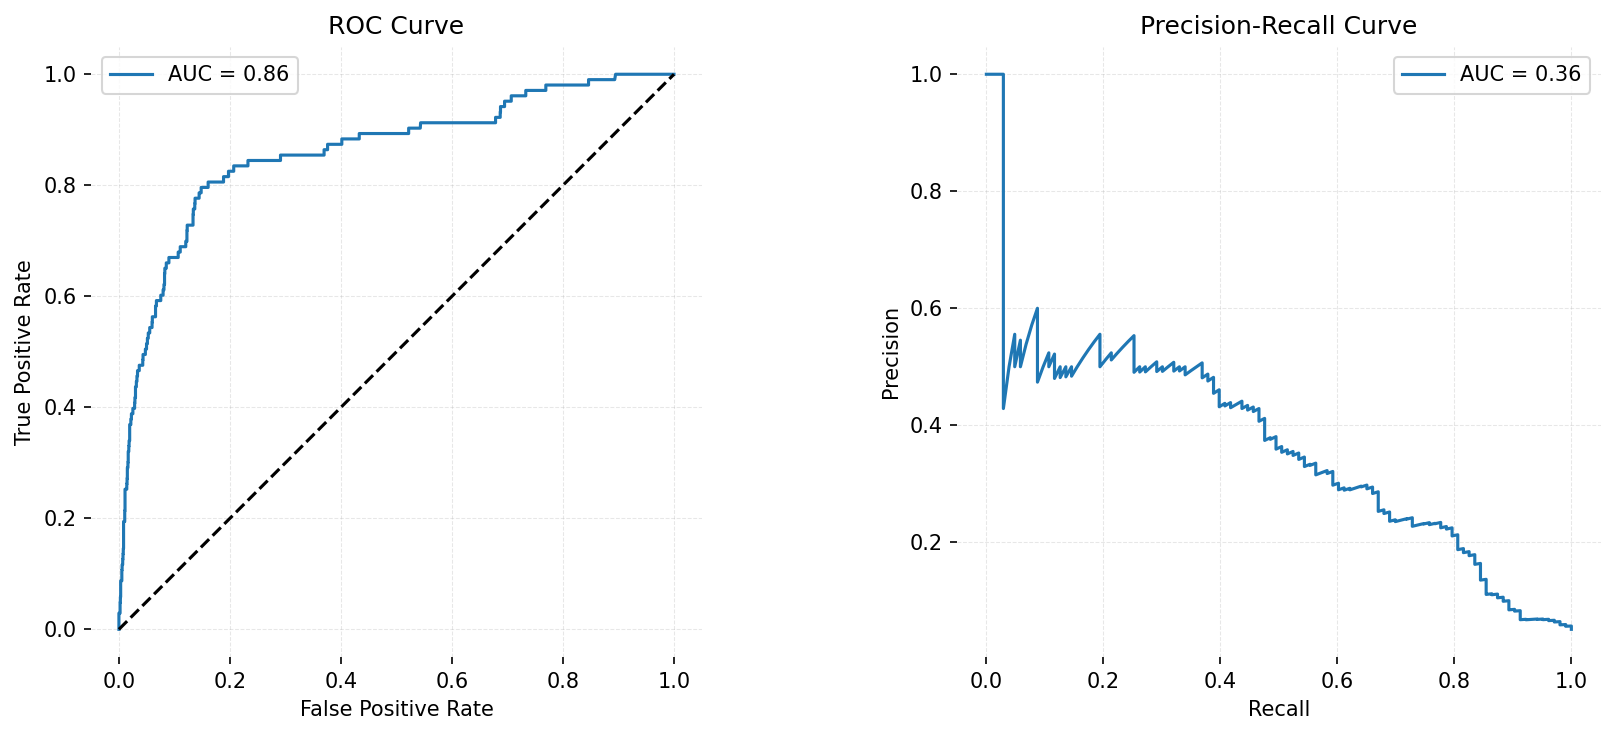

In [121]:
compute_and_plot_pr_roc_auc(y, y_scores_xgbrf_bcv)

### Oversampled Minority Class

In [141]:
X_resampled, y_resampled = SMOTE(random_state=RANDOM_SEED).fit_resample(X_label_enc.to_numpy(), y.to_numpy())
X_resampled.shape, (y_resampled == 1).sum()

((3820, 9), 1910)

In [142]:
xgbrf_clf_os = XGBRFClassifier(
    n_jobs=-1,
    random_state=RANDOM_SEED
)

y_prob_xgbrf_os = cross_val_predict(xgbrf_clf_os, X_resampled, y_resampled, cv=kfold, n_jobs=-1, method="predict_proba")
y_scores_xgbrf_os = y_prob_xgbrf_os[:, 1]

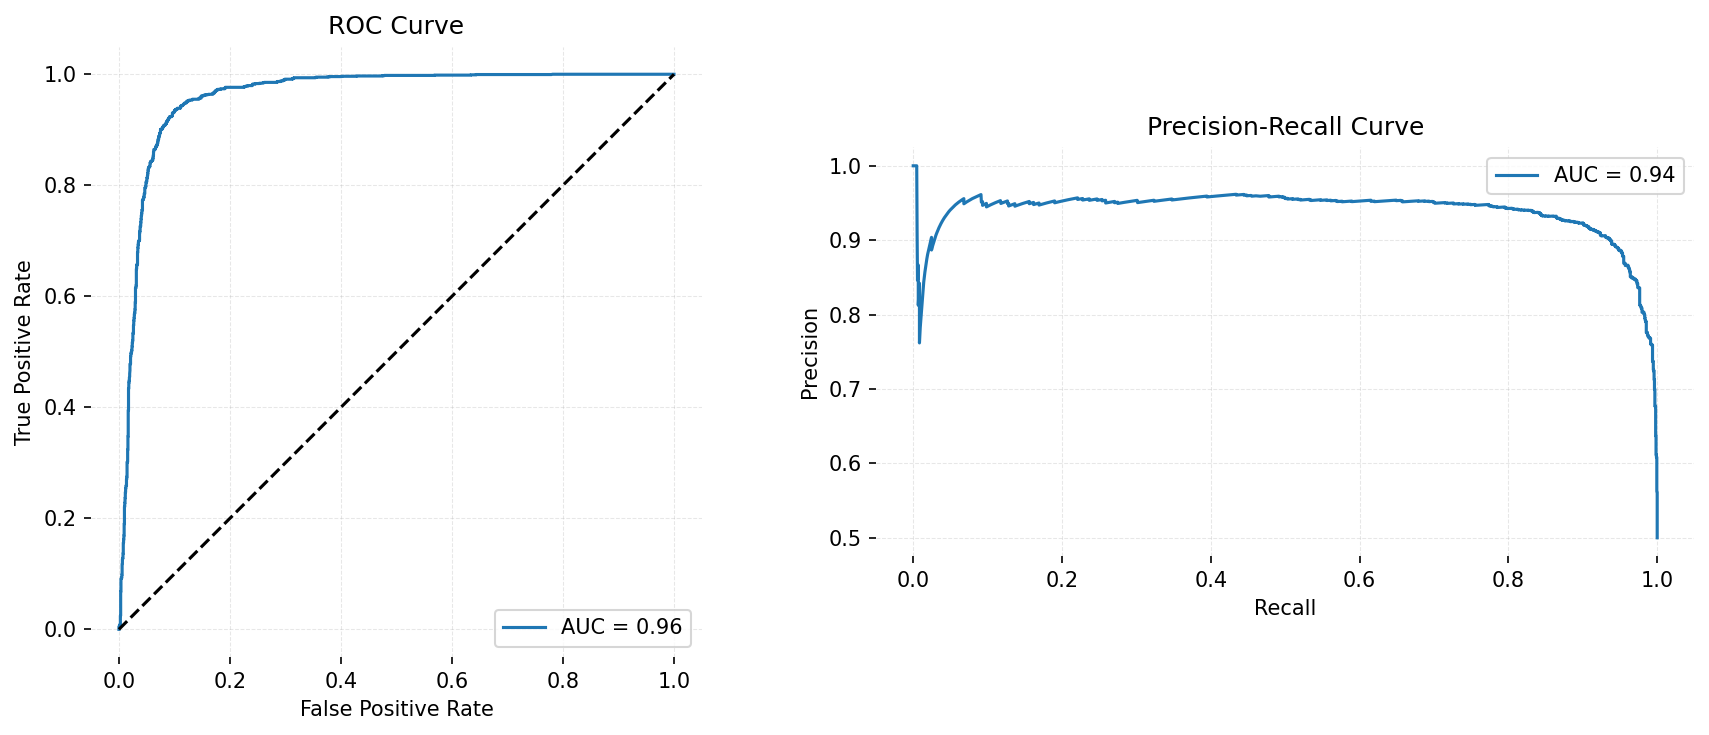

In [144]:
compute_and_plot_pr_roc_auc(y_resampled, y_scores_xgbrf_os)

### Oversampling Minority + Bayesian Search

In [148]:
search_space_pipeline = {
    "clf__n_estimators": Integer(5, 500),
    "clf__max_depth": Integer(2, 20),
    "clf__learning_rate": Real(0.0001, 0.2, prior="log-uniform"),
    "clf__subsample": Real(0.5, 1.0),
    "clf__colsample_bynode": Real(0.4, 1.0)
}

In [159]:
xgbrf_os_pipe = Pipeline([
    ('smote', SMOTE()),
    ('clf', XGBRFClassifier(random_state=RANDOM_SEED, n_jobs=-1))
])

xgbrf_os_search = BayesSearchCV(
    xgbrf_os_pipe, 
    search_space_pipeline, 
    scoring='roc_auc', 
    cv=kfold, 
    random_state=RANDOM_SEED,
    n_jobs=-1, 
    verbose=0, 
    n_iter=50
)

xgbrf_os_search.fit(X_label_enc.to_numpy(), y.to_numpy())

BayesSearchCV(cv=KFold(n_splits=5, random_state=None, shuffle=False),
              estimator=Pipeline(steps=[('smote', SMOTE()),
                                        ('clf',
                                         XGBRFClassifier(base_score=None,
                                                         booster=None,
                                                         callbacks=None,
                                                         colsample_bylevel=None,
                                                         colsample_bytree=None,
                                                         device=None,
                                                         early_stopping_rounds=None,
                                                         enable_categorical=False,
                                                         eval_metric=None,
                                                         feature_types=None,
                                                         feature_weights=None,
                                                         gamma=...
              search_spaces={'clf__colsample_bynode': Real(low=0.4, high=1.0, prior='uniform', transform='normalize'),
                             'clf__learning_rate': Real(low=0.0001, high=0.2, prior='log-uniform', transform='normalize'),
                             'clf__max_depth': Integer(low=2, high=20, prior='uniform', transform='normalize'),
                             'clf__n_estimators': Integer(low=5, high=500, prior='uniform', transform='normalize'),
                             'clf__subsample': Real(low=0.5, high=1.0, prior='uniform', transform='normalize')})

In [160]:
xgbrf_os_search.best_params_

OrderedDict([('clf__colsample_bynode', 0.4),
             ('clf__learning_rate', 0.08418811138155487),
             ('clf__max_depth', 16),
             ('clf__n_estimators', 42),
             ('clf__subsample', 0.5)])

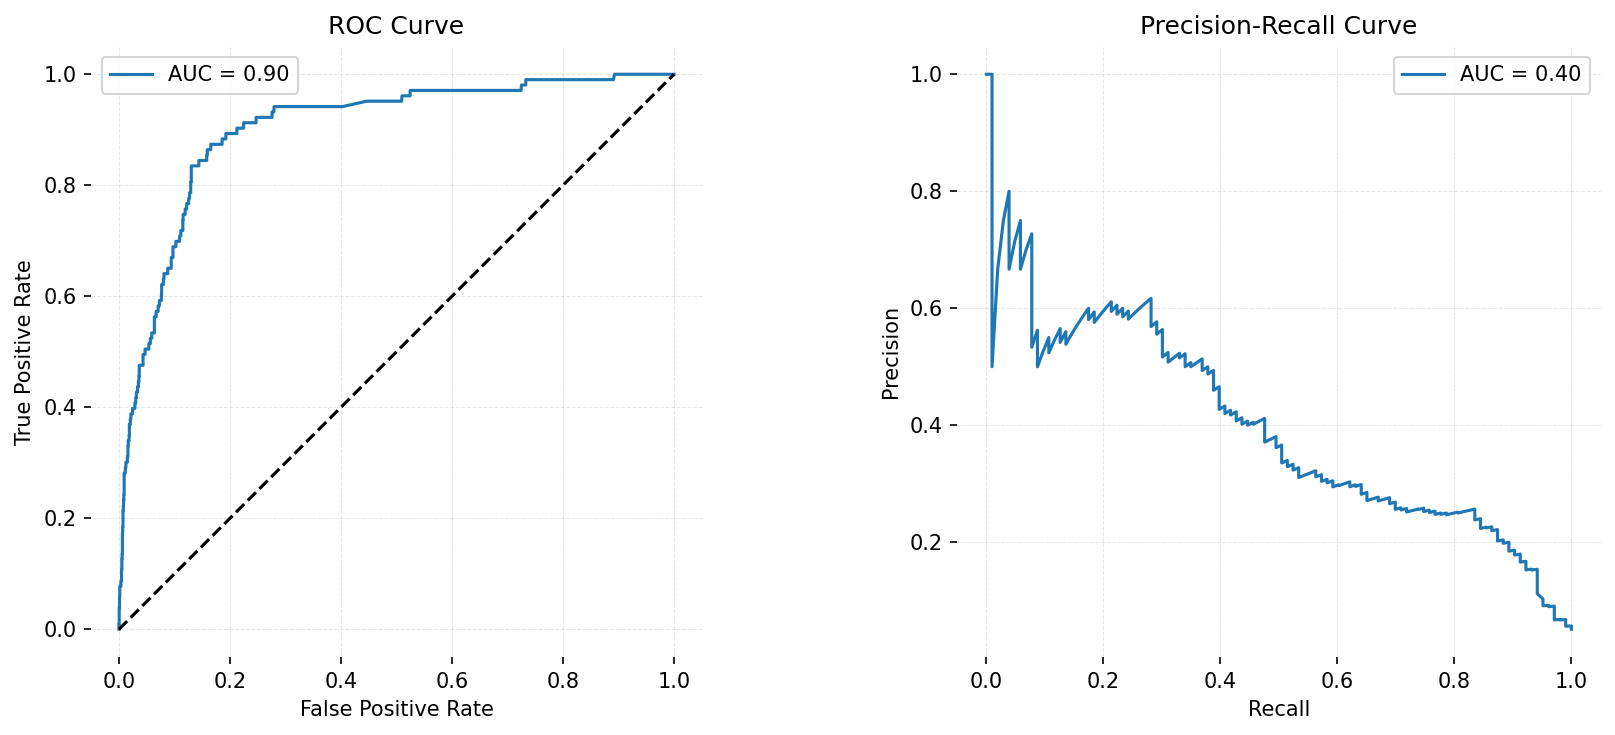

In [161]:
xgbrf_os_best = xgbrf_os_search.best_estimator_.named_steps["clf"]

y_prob_xgbrf_os_bcv = cross_val_predict(
    xgbrf_os_best, X_label_enc, y, cv=kfold, n_jobs=-1, method="predict_proba"
)
y_scores_xgbrf_os_bcv = y_prob_xgbrf_os_bcv[:, 1]

compute_and_plot_pr_roc_auc(y, y_scores_xgbrf_os_bcv)

# Linear Models

In [25]:
onehots = X.select(cat_features).to_dummies()

X_onehot_enc = pl.concat([X.drop(cat_features), onehots], how="horizontal")
X_onehot_enc.schema

Schema([('device', UInt32),
        ('auction', UInt32),
        ('ip', UInt32),
        ('url', UInt32),
        ('mean_diff_time_bids', Float64),
        ('bid_count', UInt32),
        ('has_bids_false', UInt8),
        ('has_bids_true', UInt8),
        ('merchandise_auto parts', UInt8),
        ('merchandise_books and music', UInt8),
        ('merchandise_clothing', UInt8),
        ('merchandise_computers', UInt8),
        ('merchandise_furniture', UInt8),
        ('merchandise_home goods', UInt8),
        ('merchandise_jewelry', UInt8),
        ('merchandise_mobile', UInt8),
        ('merchandise_office equipment', UInt8),
        ('merchandise_sporting goods', UInt8),
        ('merchandise_unknown', UInt8),
        ('most_frequent_country_ae', UInt8),
        ('most_frequent_country_ar', UInt8),
        ('most_frequent_country_au', UInt8),
        ('most_frequent_country_az', UInt8),
        ('most_frequent_country_ba', UInt8),
        ('most_frequent_country_bd', UInt8),
        

In [44]:
scaler = StandardScaler()

num_feats = X_onehot_enc.select(numeric_features)

scaled_feats = scaler.fit_transform(num_feats)

scaled_feats_df = pl.DataFrame(scaled_feats, schema=numeric_features)

X_onehot_enc = X_onehot_enc.with_columns([
    scaled_feats_df[col].alias(col) for col in numeric_features
])

X_onehot_enc

device,auction,ip,url,mean_diff_time_bids,bid_count,has_bids_false,has_bids_true,merchandise_auto parts,merchandise_books and music,merchandise_clothing,merchandise_computers,merchandise_furniture,merchandise_home goods,merchandise_jewelry,merchandise_mobile,merchandise_office equipment,merchandise_sporting goods,merchandise_unknown,most_frequent_country_ae,most_frequent_country_ar,most_frequent_country_au,most_frequent_country_az,most_frequent_country_ba,most_frequent_country_bd,most_frequent_country_bf,most_frequent_country_bh,most_frequent_country_bn,most_frequent_country_br,most_frequent_country_ca,most_frequent_country_ch,most_frequent_country_cl,most_frequent_country_cm,most_frequent_country_cn,most_frequent_country_de,most_frequent_country_dk,most_frequent_country_dz,…,most_frequent_country_lt,most_frequent_country_ma,most_frequent_country_mt,most_frequent_country_mx,most_frequent_country_my,most_frequent_country_mz,most_frequent_country_ng,most_frequent_country_nl,most_frequent_country_no,most_frequent_country_np,most_frequent_country_om,most_frequent_country_pa,most_frequent_country_ph,most_frequent_country_pk,most_frequent_country_pl,most_frequent_country_py,most_frequent_country_qa,most_frequent_country_ro,most_frequent_country_rs,most_frequent_country_ru,most_frequent_country_sa,most_frequent_country_sd,most_frequent_country_se,most_frequent_country_sg,most_frequent_country_so,most_frequent_country_th,most_frequent_country_tr,most_frequent_country_tz,most_frequent_country_ua,most_frequent_country_uk,most_frequent_country_unknown,most_frequent_country_us,most_frequent_country_vn,most_frequent_country_ye,most_frequent_country_za,most_frequent_country_zm,most_frequent_country_zw
f64,f64,f64,f64,f64,f64,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,…,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8
-0.339944,-0.29838,-0.135539,-0.127879,-0.30396,-0.102827,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,…,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
-0.404292,-0.414503,-0.139115,-0.127503,0.049338,-0.104266,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,…,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
-0.404292,-0.394011,-0.138905,-0.127503,-0.032258,-0.104198,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,…,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
-0.409654,-0.414503,-0.139536,-0.127879,-0.424182,-0.104403,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,…,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
-0.130814,-0.264226,-0.113867,-0.094006,-0.407207,-0.093849,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,…,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
-0.393567,-0.250564,-0.138695,-0.127503,0.024106,-0.102005,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,…,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0
-0.409654,-0.414503,-0.139536,-0.127879,-0.424182,-0.104403,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,…,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0
-0.404292,-0.414503,-0.139326,-0.127879,0.651971,-0.104335,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,…,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


## Support Vector Machines

### Baseline

In [93]:
svm_clf = SVC(random_state=RANDOM_SEED, class_weight="balanced", kernel="rbf", C=1)

In [94]:
y_prob_svm = cross_val_predict(svm_clf, X_onehot_enc, y, cv=kfold, n_jobs=-1, method="decision_function")
y_scores_svm = y_prob_svm

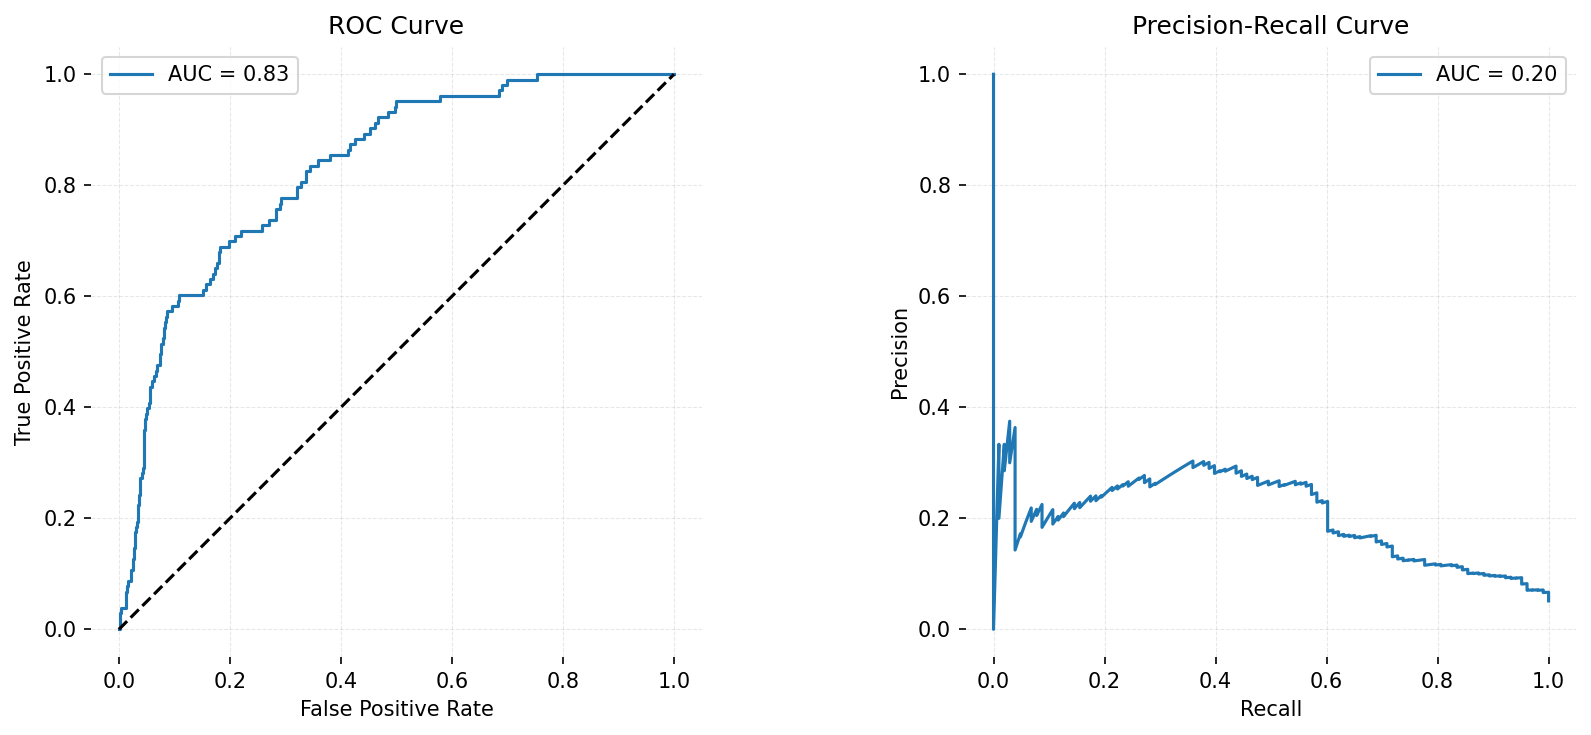

In [95]:
compute_and_plot_pr_roc_auc(y, y_scores_svm)

The baseline SVM seems less stable than a baseline Random Forest for this dataset

## Logistic Regression

### Baseline

In [133]:
lr_clf = LogisticRegression(random_state=RANDOM_SEED, class_weight="balanced")

In [134]:
y_prob_lr = cross_val_predict(lr_clf, X_onehot_enc, y, cv=kfold, n_jobs=-1, method="predict_proba")
y_scores_lr = y_prob_lr[:, 1]

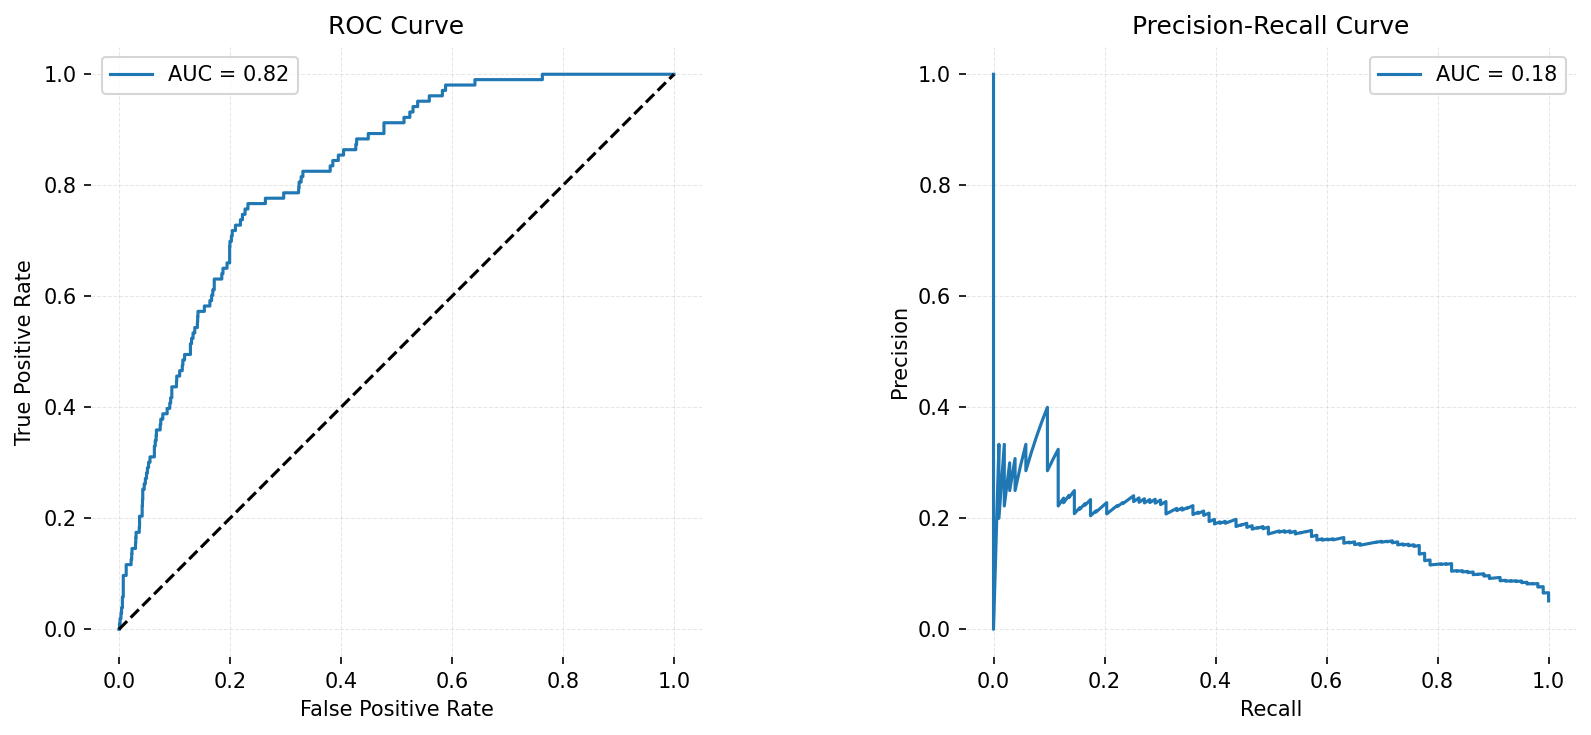

In [135]:
compute_and_plot_pr_roc_auc(y, y_scores_lr)

# Submissions

## XGBRFClassifier - undefeated best

In [127]:
test_processed = test_processed.drop(["bidder_id", "payment_account", "address"])
test_processed = test_processed.with_columns(
    pl.lit(LabelEncoder().fit_transform(test_processed["has_bids"])).alias("has_bids"),
    pl.lit(LabelEncoder().fit_transform(test_processed["merchandise"])).alias("merchandise"),
    pl.lit(LabelEncoder().fit_transform(test_processed["most_frequent_country"])).alias("most_frequent_country"),
)

test_processed

device,auction,merchandise,ip,url,most_frequent_country,mean_diff_time_bids,bid_count,has_bids
u32,u32,i64,u32,u32,i64,f64,u32,i64
2,3,4,4,3,17,1.7556e13,4,1
3,2,8,2,1,6,2.5334e13,3,1
4,14,6,4,2,32,1.7121e10,17,1
81,90,3,129,80,41,5.1704e11,148,1
17,20,5,17,1,86,2.8586e11,23,1
…,…,…,…,…,…,…,…,…
9,41,6,22,4,80,6.8453e10,983,1
29,32,8,49,18,32,2.0284e11,66,1
376,419,4,1460,1049,35,3.5746e10,2162,1


In [131]:
xgbrf_clf.fit(X_label_enc, y)
y_probas = xgbrf_clf.predict_proba(test_processed)

pl.DataFrame([y_probas[:, 1], test["bidder_id"]], schema=["prediction", "bidder_id"]).write_csv(DATA_PATH + "xgbrf.csv")

## XGBRFClassifier with minority class upsampled

In [146]:
xgbrf_clf_os = xgbrf_clf_os.fit(X_resampled, y_resampled)
y_probas = xgbrf_clf_os.predict_proba(test_processed)

pl.DataFrame([y_probas[:, 1], test["bidder_id"]], schema=["prediction", "bidder_id"]).write_csv(DATA_PATH + "xgbrf_upsampled.csv")

## XGBRFClassifier + minority oversampled + hyperparameter search

In [162]:
xgbrf_os_best.fit(X_resampled, y_resampled)
y_probas = xgbrf_os_best.predict_proba(test_processed)

pl.DataFrame([y_probas[:, 1], test["bidder_id"]], schema=["prediction", "bidder_id"]).write_csv(DATA_PATH + "xgbrf_upsampled_tuned.csv")